# 04. Relationships & Confounding

**Goal:** Learn to look at correlations skeptically before building models.

## Why This Matters

Marketing teams often jump to conclusions like:
- "Email spend is up and revenue is up — emails are working!"
- "We increased ads in December and revenue spiked — ads drove the spike!"

But what if something else caused *both* changes? 

This notebook explores how **confounding variables** (like seasonality or day-of-week patterns) can create misleading correlations between marketing spend and revenue.

---
## Dataset

**Source:** Synthetic data generated for educational purposes  
**File:** `marketing_ad_spend_data.csv`  
**Period:** 365 days (full year 2023)  
**Variables:** Daily ad spend (Google, Facebook, Email), revenue, transactions, AOV

The dataset was specifically designed to include realistic confounding factors commonly found in marketing analytics (seasonality, day-of-week effects) to practice identifying spurious correlations.

---

## What We'll Do

1. Plot relationships between variables (scatter plots)
2. Calculate correlations
3. Introduce confounders and show how the story changes
4. Document examples where correlation ≠ causation

## 1. Setup & Data Loading

First, we'll import the libraries we need and load the data.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

In [27]:
# Load the data
df = pd.read_csv('marketing_ad_spend_data.csv')

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Quick look at the data
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.head()

Dataset shape: (365, 10)
Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


,date,day_of_week,is_weekend,google_ads_spend,facebook_ads_spend,email_spend,total_ad_spend,revenue,transactions,avg_order_value
0,2023-01-01,6,1,2159.34,1423.20,519.58,4102.12,15436.24,318,48.54
1,2023-01-02,0,0,1979.17,1551.70,402.16,3933.03,16869.96,447,37.74
2,2023-01-03,1,0,2225.28,1512.84,540.83,4278.95,15417.30,322,47.88
3,2023-01-04,2,0,2498.19,1533.30,329.74,4361.23,18748.80,452,41.48
4,2023-01-05,3,0,1981.33,1362.59,602.92,3946.84,17213.85,389,44.25


## 2. Initial Data Exploration

Before looking at relationships, let's understand what variables we have.

In [28]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                365 non-null    datetime64[us]
 1   day_of_week         365 non-null    int64         
 2   is_weekend          365 non-null    int64         
 3   google_ads_spend    365 non-null    float64       
 4   facebook_ads_spend  365 non-null    float64       
 5   email_spend         365 non-null    float64       
 6   total_ad_spend      365 non-null    float64       
 7   revenue             365 non-null    float64       
 8   transactions        365 non-null    int64         
 9   avg_order_value     365 non-null    float64       
dtypes: datetime64[us](1), float64(6), int64(3)
memory usage: 28.6 KB


In [29]:
# Summary statistics for key business metrics
df[['google_ads_spend', 'facebook_ads_spend', 'email_spend', 
    'total_ad_spend', 'revenue', 'transactions', 'avg_order_value']].describe().round(2)

,google_ads_spend,facebook_ads_spend,email_spend,total_ad_spend,revenue,transactions,avg_order_value
count,365.00,365.00,365.00,365.00,365.00,365.00,365.00
mean,2170.28,1492.40,541.19,4203.86,17569.19,367.06,50.36
std,550.30,244.53,121.70,675.52,3694.89,124.41,9.99
min,500.00,762.64,215.15,2253.54,9078.23,163.00,20.78
25%,1778.82,1328.66,453.23,3732.64,14489.68,280.00,43.81
50%,2225.28,1489.56,527.16,4292.12,18474.39,354.00,49.82
75%,2587.22,1653.00,607.87,4712.62,20325.30,427.00,57.12
max,3428.85,2300.63,945.53,6132.42,26278.43,963.00,81.78


## 3. Relationship 1: Total Ad Spend vs Revenue

**The Naïve Question:** "Do ads drive revenue?"

Let's start with the most obvious relationship — does total ad spend correlate with revenue?

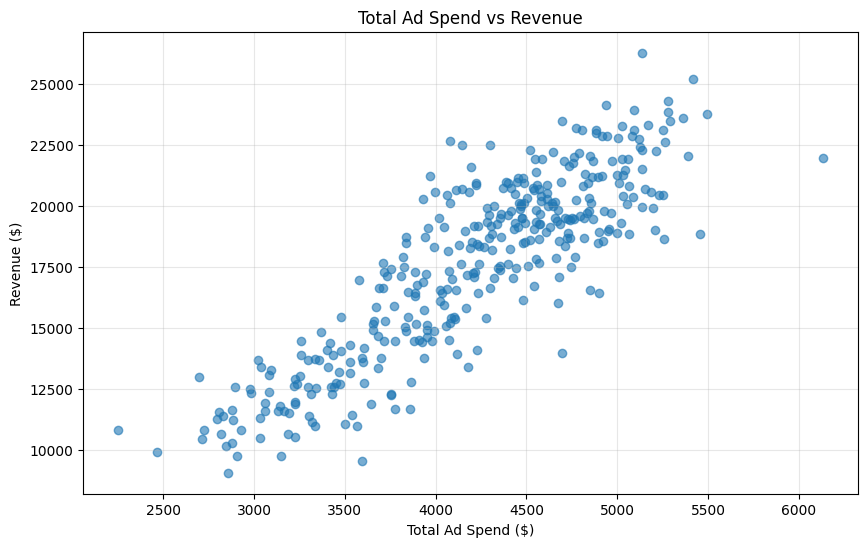

Correlation coefficient: 0.868


In [30]:
# Scatter plot: Total Ad Spend vs Revenue
plt.figure(figsize=(10, 6))
plt.scatter(df['total_ad_spend'], df['revenue'], alpha=0.6)
plt.xlabel('Total Ad Spend ($)')
plt.ylabel('Revenue ($)')
plt.title('Total Ad Spend vs Revenue')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate correlation
correlation = df['total_ad_spend'].corr(df['revenue'])
print(f"Correlation coefficient: {correlation:.3f}")

### Initial Observation

The scatter plot shows a strong positive correlation between total ad spend and revenue. 

**Correlation coefficient:** 0.868

**What a marketer might conclude:** "Ads are clearly driving revenue! We should increase ad spend!"

**But wait...** what if something else is causing *both* ad spend and revenue to increase together?

### Introducing Time: The Hidden Confounder

Let's plot both variables over time to see if there's a pattern we're missing.

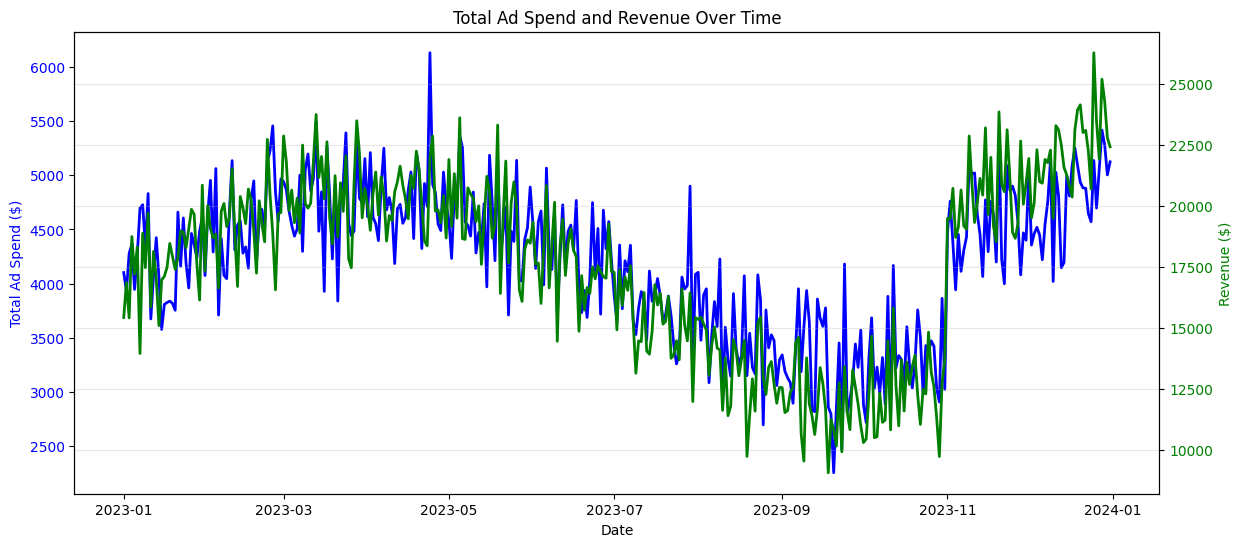

In [31]:
# Plot both variables over time
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot ad spend on left y-axis
ax1.plot(df['date'], df['total_ad_spend'], color='blue', label='Total Ad Spend', linewidth=2)
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Ad Spend ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Plot revenue on right y-axis
ax2 = ax1.twinx()
ax2.plot(df['date'], df['revenue'], color='green', label='Revenue', linewidth=2)
ax2.set_ylabel('Revenue ($)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Total Ad Spend and Revenue Over Time')
plt.grid(True, alpha=0.3)
plt.show()

### Key Observation: Seasonality

Both ad spend and revenue spike together throughout the year, with the **largest spike in Q4 (November-December)**.

**The confounder revealed: Seasonality**

- Companies increase ad budgets in Q4 for holiday shopping
- Revenue naturally spikes in Q4 due to holiday demand
- **Both variables are driven by the same underlying factor: the holiday season**

This means our correlation of 0.868 is **inflated by seasonality** — it's not purely a causal relationship between ads and revenue.

### Controlling for Seasonality

To see if the relationship holds *within* seasons, let's look at the relationship separately for each month.

If seasonality is the main driver, the correlation should weaken when we look within individual months.

In [32]:
# Add month column for grouping
df['month'] = df['date'].dt.month

# Calculate correlation within each month
monthly_correlations = df.groupby('month').apply(
    lambda x: x['total_ad_spend'].corr(x['revenue'])
)

print("Correlation by month:")
print(monthly_correlations.round(3))
print(f"\nAverage within-month correlation: {monthly_correlations.mean():.3f}")
print(f"Original (naive) correlation: 0.868")

Correlation by month:
month
1     0.271
2     0.328
3     0.523
4     0.305
5     0.544
6     0.621
7     0.689
8     0.686
9     0.572
10    0.646
11    0.369
12    0.628
dtype: float64

Average within-month correlation: 0.515
Original (naive) correlation: 0.868


### Results: Seasonality Inflates the Correlation

**Key Finding:**
- **Naïve correlation:** 0.868
- **Within-month correlation:** 0.515 (average)
- **Difference:** 0.353 (40.7% of the relationship was spurious!)

**Interpretation:**

When we control for seasonality by looking within individual months, the correlation drops substantially. This tells us that a significant portion of the original 0.868 correlation was driven by both variables spiking together during the holiday season — not purely by ads driving revenue.

There's still a positive relationship (0.515), which suggests ads *do* have some effect, but it's weaker than the naïve analysis suggested.

**Marketing takeaway:** Don't measure ad effectiveness by comparing high-spend periods (Q4) to low-spend periods (Q1) — you'll confuse seasonal demand with ad impact!

## 4. Relationship 2: Email Spend vs Revenue on Fridays

**The Naïve Question:** "Do Friday email campaigns drive revenue?"

Marketing teams often launch email campaigns on Fridays. Let's see if email spend correlates with revenue, and whether **day of week** might be a confounder.

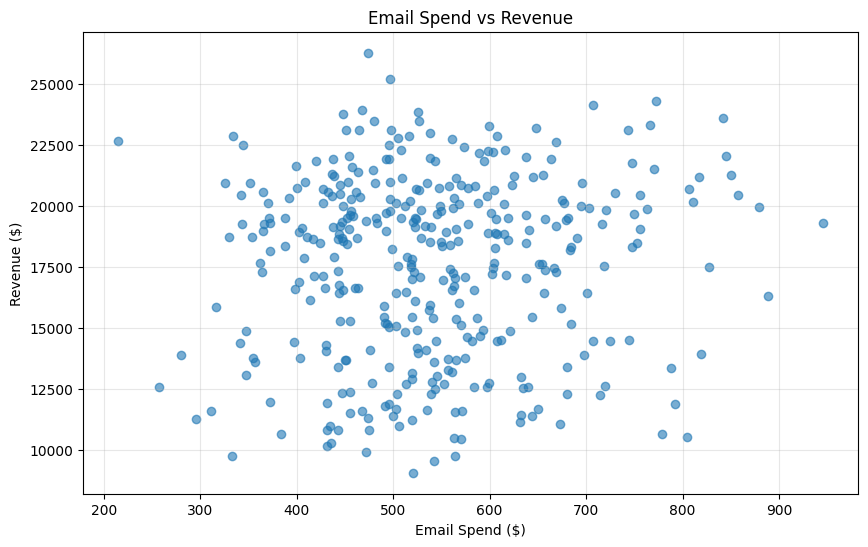

Correlation coefficient: 0.069


In [33]:
# Scatter plot: Email Spend vs Revenue
plt.figure(figsize=(10, 6))
plt.scatter(df['email_spend'], df['revenue'], alpha=0.6)
plt.xlabel('Email Spend ($)')
plt.ylabel('Revenue ($)')
plt.title('Email Spend vs Revenue')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate correlation
email_correlation = df['email_spend'].corr(df['revenue'])
print(f"Correlation coefficient: {email_correlation:.3f}")

### Initial Observation

The scatter plot shows almost no relationship between email spend and revenue.

**Correlation coefficient: 0.069**

**What this means:** Unlike total ad spend, email spend doesn't appear to correlate with revenue at the daily level.

But let's investigate further — maybe email spend varies by **day of week**, and so does revenue. Let's check if there's a day-of-week pattern hiding in the data.

In [34]:
# Check average email spend by day of week
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
email_by_day = df.groupby('day_of_week')['email_spend'].mean()
email_by_day.index = day_names

print("Average Email Spend by Day of Week:")
print(email_by_day.round(2))

Average Email Spend by Day of Week:
Monday       524.54
Tuesday      496.19
Wednesday    488.41
Thursday     546.35
Friday       725.85
Saturday     508.69
Sunday       499.09
Name: email_spend, dtype: float64


In [35]:
# Check average revenue by day of week
revenue_by_day = df.groupby('day_of_week')['revenue'].mean()
revenue_by_day.index = day_names

print("Average Revenue by Day of Week:")
print(revenue_by_day.round(2))

Average Revenue by Day of Week:
Monday       17964.02
Tuesday      17655.95
Wednesday    18063.25
Thursday     18111.75
Friday       18142.01
Saturday     16576.89
Sunday       16491.17
Name: revenue, dtype: float64


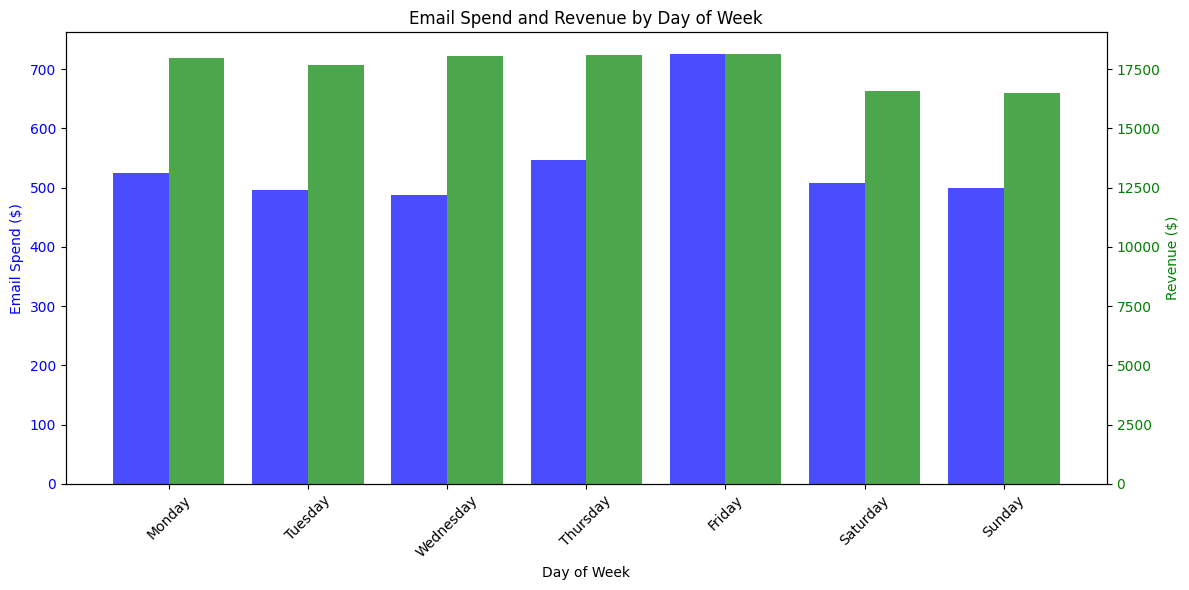

In [36]:
# Visual comparison: Email spend and revenue by day of week
fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(7)
ax1.bar([i - 0.2 for i in x], email_by_day, width=0.4, label='Email Spend', alpha=0.7, color='blue')
ax1.set_xlabel('Day of Week')
ax1.set_ylabel('Email Spend ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(day_names, rotation=45)

ax2 = ax1.twinx()
ax2.bar([i + 0.2 for i in x], revenue_by_day, width=0.4, label='Revenue', alpha=0.7, color='green')
ax2.set_ylabel('Revenue ($)', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Email Spend and Revenue by Day of Week')
plt.tight_layout()
plt.show()

We see that revenue is fairly flat from Monday to Friday, whereas email spend is not. This explains why we got no correlation.

### Exploring Weekend Effects

Let's see if the email-revenue relationship differs between weekdays and weekends.

In [37]:
# Split by weekend/weekday
weekday_corr = df[df['is_weekend'] == 0]['email_spend'].corr(df[df['is_weekend'] == 0]['revenue'])
weekend_corr = df[df['is_weekend'] == 1]['email_spend'].corr(df[df['is_weekend'] == 1]['revenue'])

print(f"Weekday correlation (email vs revenue): {weekday_corr:.3f}")
print(f"Weekend correlation (email vs revenue): {weekend_corr:.3f}")
print(f"Overall correlation: 0.069")

Weekday correlation (email vs revenue): 0.035
Weekend correlation (email vs revenue): 0.038
Overall correlation: 0.069


### Results: Day-of-Week Patterns Don't Create Spurious Correlation

**Key Finding:**
- **Overall correlation:** 0.069
- **Weekday correlation:** 0.035
- **Weekend correlation:** 0.038

**Interpretation:**

Unlike the ad spend example, email spend and revenue show **almost no correlation**, even when we account for day-of-week patterns. 

While both variables do vary by day of week, their patterns don't align enough to create a spurious correlation. This is actually a good example of when **no confounding occurs** — just because two variables each vary with a third variable (day of week) doesn't automatically mean they'll correlate with each other.

**Marketing takeaway:** Email spend at the daily level doesn't correlate with same-day revenue in this dataset. This is a reminder that not all marketing channels show immediate, linear relationships with outcomes.

## 5. Relationship 3: Transactions vs Revenue

**The Naïve Question:** "More transactions = more revenue, right?"

This seems obvious — of course more orders means more revenue! But let's see if **Average Order Value (AOV)** and **day-of-week patterns** complicate this simple relationship.

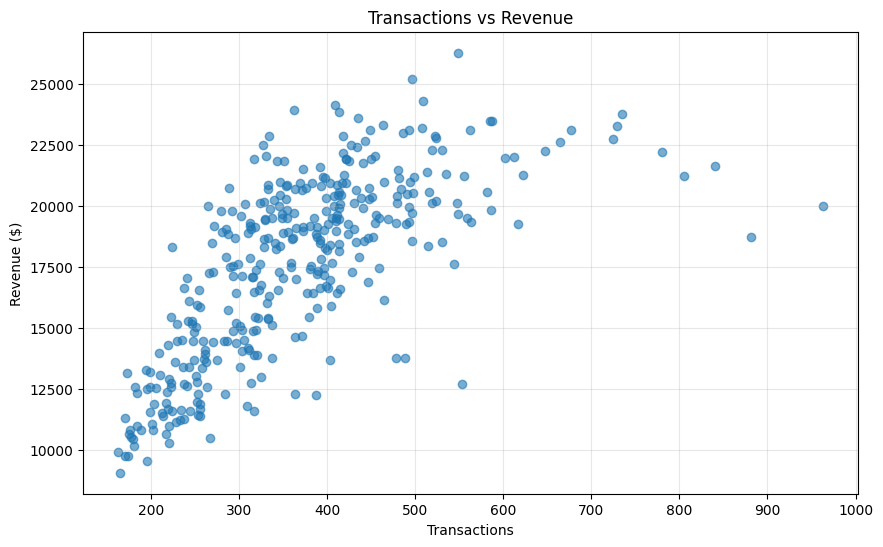

Correlation coefficient: 0.699


In [38]:
# Scatter plot: Transactions vs Revenue
plt.figure(figsize=(10, 6))
plt.scatter(df['transactions'], df['revenue'], alpha=0.6)
plt.xlabel('Transactions')
plt.ylabel('Revenue ($)')
plt.title('Transactions vs Revenue')
plt.grid(True, alpha=0.3)
plt.show()

# Calculate correlation
trans_correlation = df['transactions'].corr(df['revenue'])
print(f"Correlation coefficient: {trans_correlation:.3f}")

### Exploring the Weekend Effect on AOV

Let's color the scatter plot by weekend vs weekday to see if that explains the pattern break you observed.

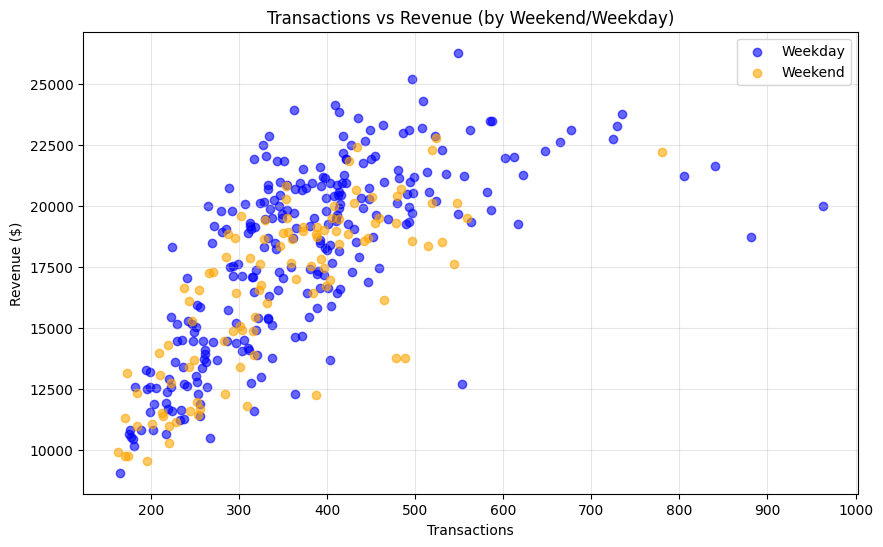

In [39]:
# Scatter plot colored by weekend/weekday
plt.figure(figsize=(10, 6))
weekend_data = df[df['is_weekend'] == 1]
weekday_data = df[df['is_weekend'] == 0]

plt.scatter(weekday_data['transactions'], weekday_data['revenue'], 
           alpha=0.6, label='Weekday', color='blue')
plt.scatter(weekend_data['transactions'], weekend_data['revenue'], 
           alpha=0.6, label='Weekend', color='orange')

plt.xlabel('Transactions')
plt.ylabel('Revenue ($)')
plt.title('Transactions vs Revenue (by Weekend/Weekday)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
# Check AOV patterns
print("Average Order Value by weekend/weekday:")
print(f"Weekday AOV: ${df[df['is_weekend'] == 0]['avg_order_value'].mean():.2f}")
print(f"Weekend AOV: ${df[df['is_weekend'] == 1]['avg_order_value'].mean():.2f}")
print(f"\nOverall AOV range: ${df['avg_order_value'].min():.2f} to ${df['avg_order_value'].max():.2f}")

Average Order Value by weekend/weekday:
Weekday AOV: $50.53
Weekend AOV: $49.92

Overall AOV range: $20.78 to $81.78


In [41]:
# Split data by transaction volume
high_transaction_days = df[df['transactions'] >= 600]
low_transaction_days = df[df['transactions'] < 600]

print(f"Days with <600 transactions: {len(low_transaction_days)}")
print(f"Days with ≥600 transactions: {len(high_transaction_days)}")
print(f"\nCorrelation for <600 transactions: {low_transaction_days['transactions'].corr(low_transaction_days['revenue']):.3f}")
print(f"Correlation for ≥600 transactions: {high_transaction_days['transactions'].corr(high_transaction_days['revenue']):.3f}")

# Check when these high-transaction days occur
print(f"\nMonths with ≥600 transactions:")
print(high_transaction_days['month'].value_counts().sort_index())

Days with <600 transactions: 350
Days with ≥600 transactions: 15

Correlation for <600 transactions: 0.744
Correlation for ≥600 transactions: -0.354

Months with ≥600 transactions:
month
2     1
3     3
4     3
5     2
11    2
12    4
Name: count, dtype: int64


### Discovery: Non-Linear Relationship at High Transaction Volumes

Interestingly, the relationship between transactions and revenue **reverses** at high transaction volumes (≥600).

- **Below 600 transactions:** Positive correlation (more transactions → more revenue)
- **Above 600 transactions:** Negative correlation (-0.3) (more transactions → *less* revenue?!)

This suggests that on very high-volume days, something else is happening — possibly discounting, promotional sales, or lower-value bulk orders that increase transaction count but reduce overall revenue efficiency.

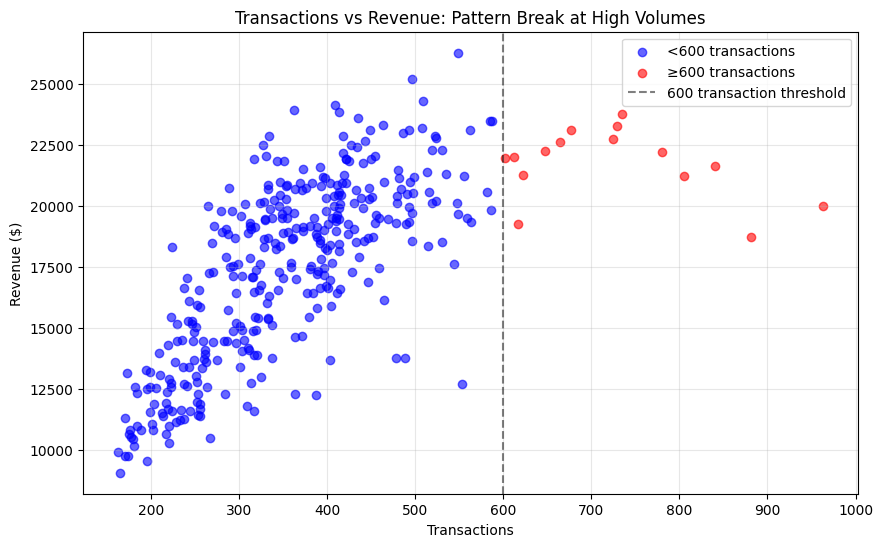

In [42]:
# Visualize the pattern break
plt.figure(figsize=(10, 6))
plt.scatter(low_transaction_days['transactions'], low_transaction_days['revenue'], 
           alpha=0.6, label='<600 transactions', color='blue')
plt.scatter(high_transaction_days['transactions'], high_transaction_days['revenue'], 
           alpha=0.6, label='≥600 transactions', color='red')
plt.axvline(x=600, color='black', linestyle='--', alpha=0.5, label='600 transaction threshold')
plt.xlabel('Transactions')
plt.ylabel('Revenue ($)')
plt.title('Transactions vs Revenue: Pattern Break at High Volumes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Summary: Key Lessons on Correlation vs Causation

### Examples Where Correlation ≠ Causation

**1. Total Ad Spend vs Revenue (Seasonality Confounder)**
- Naïve correlation: 0.868
- Within-month correlation: 0.515
- **40.7% of the relationship was spurious**, driven by Q4 seasonality affecting both variables
- **Insight:** Always check if time-based patterns (seasonality) are driving correlations

**2. Email Spend vs Revenue (No Clear Confounding)**
- Correlation: 0.069 (essentially none)
- Day-of-week patterns exist for both variables but don't align
- **Insight:** Not all marketing channels show immediate linear relationships with revenue

**3. Transactions vs Revenue (Non-Linear Relationship)**
- Overall correlation: 0.699
- Below 600 transactions: strong positive correlation
- Above 600 transactions: negative correlation (-0.3)
- **Insight:** Relationships can be non-linear; high-volume days operate under different dynamics (likely promotions/discounting)

### What Would Be Needed to Establish Causation?

To move from correlation to causation, we would need:
- **Randomized experiments** (A/B tests with treatment and control groups)
- **Natural experiments** (unexpected external events that create quasi-random variation)
- **Controlled regression models** with proper controls for confounders (in future exercises)
- **Time-based analysis** (lagged effects, difference-in-differences)

### Key Takeaway

**Correlation is a starting point for investigation, not a conclusion.** Always ask: "What else could explain both variables moving together?"